# Introduction

This project aims to analyse historical stock data to study returns, volatility and correlations between major tech companies. Our study will focus on Microsoft, Apple, AMD and Nvidia.

# Project

 ## Module imports

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

## Data import and visualization

[*********************100%***********************]  4 of 4 completed


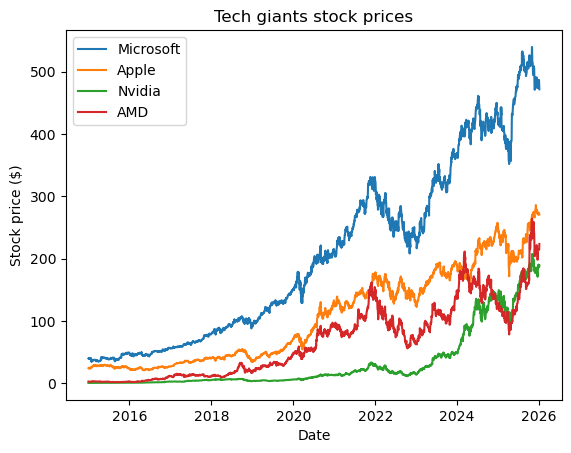

In [21]:
tickers = ["MSFT", "AAPL", "NVDA", "AMD"]

data = yf.download(tickers, start="2015-01-01", end="2026-01-04", auto_adjust = True) #Price adjusted for corporate actions

data = data["Close"]
label = ["Microsoft", "Apple", "Nvidia", "AMD"]

def data_plot(data, tickers, s_label, title, xlabel, ylabel, t_pose):
    i=0
    for ticker in tickers:
        plt.plot(data[ticker], label=label[i])
        i = i+1
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.legend(loc = t_pose)
    plt.show();

data_plot(data ,tickers, label, "Tech giants stock prices", "Date", "Stock price ($)", "upper left")

## Growth comparision through data normalization 

The graph above provides a visual answer to the evolution of our studied companies' prices. Yet since stocks have different prices ranges, in its current state our data is unable to provide a clear comparison between studied stocks.

We will rescale all stock prices so that they start at the same reference point, here this point is 1.

This part aims to answer the question "If I had invested x amount into a stock, which would have performed better ?"

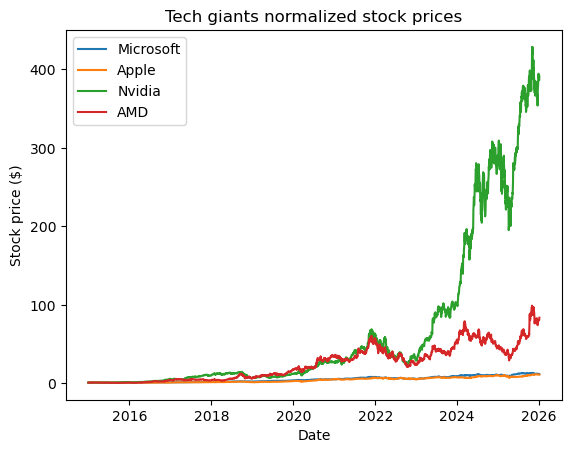

In [22]:
normalized = data / data.iloc[0] #divide by first value for all stocks, starting point = 1

data_plot(normalized, tickers, label, "Tech giants normalized stock prices", "Date", "Stock price ($)", "upper left")

The first obvious observation is that Nvidia is clearly the best performing stock of our study group. This means that for every dollar invested in 2016, the investor would've gained about $400. Leading to other stocks looking flat in comparison, not because they're bad but because they are overshadowed by Nvidia.

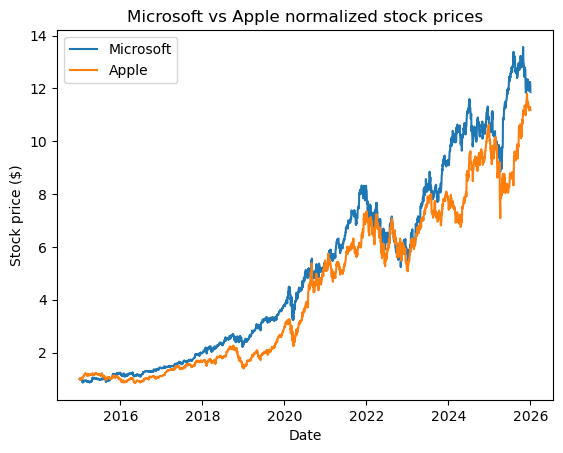

In [23]:
data_plot(normalized[["MSFT","AAPL"]], tickers[:2], label[:2], "Microsoft vs Apple normalized stock prices", "Date", "Stock price ($)", "upper left")

By plotting exclusively the lower bracket, growth of Microsoft and Apple is much more striking, it is also much more obvious how positively correlated Apple is with Microsoft greatly limiting diversification.

In a nutshell, one stock with extreme performance (Nvidia) can dominate a normalized price chart, making it difficult to actually compare their assets. Alternative scaling (such as logarithmic scale) provides a more balanced view.

## Return computation


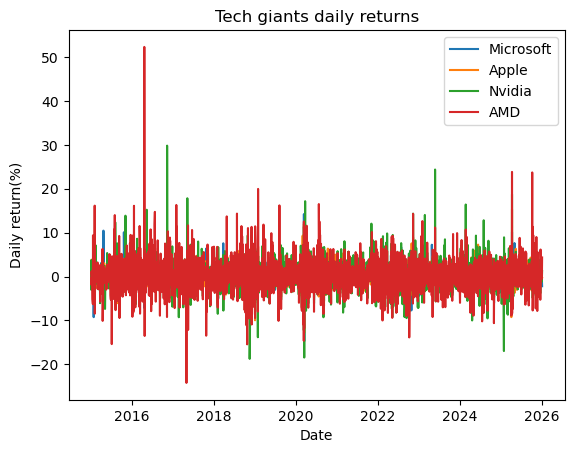

In [24]:
returns = data.pct_change().dropna() #dropna to get rid of all NaN values
returns = returns * 100
returns.rolling(30).mean() #30 day average for clarity

data_plot(returns, tickers, label, "Tech giants daily returns", "Date", "Daily return(%)", "upper right")


As seen on the graph, AMD followed by Nvidia have the widest range of variations during our studied time period, we even observe a large spike of 50% in 2016, this is an exceptionally high day return.

The first culprit could be the scale of our graph, to fit 10 years of data on a single graph, scales have to be reduced, leading to a maybe 2-3 weeks increase looking very sudden. However, in order to verify that there was no computation error, we will track down the exact day/period corresponding to the spike and verify coherence by cross referencing financial press articles on said day.

In [25]:
returns.loc["2016"]
returns["AMD"].sort_values(ascending=False).head()

Date
2016-04-22    52.290083
2025-04-09    23.820480
2025-10-06    23.708028
2019-01-30    19.948053
2020-07-24    16.501598
Name: AMD, dtype: float64

Since the calculations are correct, we looked up if there were any announcements or earnings report from AMD on this day.

The spike represented in the graph above happened 2016-04-22, financial press speaks of the "best day [for AMD shares] in over 40 years" [Market watch article](https://www.marketwatch.com/story/amds-stock-has-best-day-in-40-years-after-china-jv-deal-q1-results-2016-04-22 ) and another article from Yahoo Finance explains [why AMD's stock price jumped 50% in a day](https://finance.yahoo.com/news/why-did-amd-stock-jump-154505561.html?guccounter=1). The apparent reasons for the spike were strong 2016 Q1 performance coupled with a licensing agreement with China and design wins for 3 semi-custom processors.

Furthermore, this jump is also explained by the low price of AMD's shares in 2016, leading to an incredibly high return.

In short, large apparent spikes in returns can result from low initial price levels, big news or earnings anouncements. Zooming into shorter timeframes helps better interpret these movements.

Furthermore, since some assets exhibit extreme daily returns, such as AMD with moves exceeding 50% in a single trading day, these outliers highlight the high volatility of certain stocks, particularly during periods of structural change, crisis, or market uncertainty. And thus, larger positive returns are often associated with higher overall volatility, showing that a strong performance comes with significant risk.

## Summary statistics: Mean return and Volatility computation

Some very important statistics are mean return and volatility, as of now our return data is unusable because of the sheer high number of variations in our 10 year span. This issue is solved by calculating the mean daily return of each stock.

In [26]:
returns_stats = pd.DataFrame()
TRADING_DAYS = 252
returns_stats["mean daily return"] = returns.mean()
returns_stats["mean yearly return"] = returns_stats["mean daily return"] * TRADING_DAYS
returns_stats.head()


,mean daily return,mean yearly return
Ticker,,
AAPL,0.103798,26.157199
AMD,0.227157,57.243591
MSFT,0.103795,26.156335
NVDA,0.262592,66.173188


This gives us daily expected return which in its own is insufficient in order to evaluate real growth, explaining the use of the mean yearly return.

However, in order to evaluate the certainty of that expected gain, we have to study Volatility.

In [27]:
returns_stats["Day Volatility"] = returns.std()
returns_stats["Yearly Volatility"] = returns_stats["Day Volatility"] * np.sqrt(TRADING_DAYS)
returns_stats.head()

,mean daily return,mean yearly return,Day Volatility,Yearly Volatility
Ticker,,,,
AAPL,0.103798,26.157199,1.816804,28.840873
AMD,0.227157,57.243591,3.705338,58.820414
MSFT,0.103795,26.156335,1.694055,26.892290
NVDA,0.262592,66.173188,3.066810,48.684098


As expected, the stocks with the highest day/yearly volatility are Nvidia and AMD while Microsoft and Apple have a volatility two times smaller. Microsoft and Apple are relatively less volatile, on the contrary Nvidia and AMD record extremely high volatility, showcasing signifiantly higher risk levels.


This difference is reflected in their growth patterns, Nvidia and AMD have experienced a rapid and spectacular growth while Microsoft and Apple play the long and steady game. This highlights the aggressive and risky nature of Nvidia and AMD as assets.

## Risk evaluation and Sharpe's ratio

Sharpe's ratio represents how much return you get per unit of risk. Simply put, high return and low risk are important, the Sharpe's ratio tells us how efficiently we combine both.

In [28]:
sharpe_ratio = returns_stats["mean yearly return"] / returns_stats["Yearly Volatility"]
sharpe_ratio.head()

Ticker
AAPL    0.906949
AMD     0.973193
MSFT    0.972633
NVDA    1.359236
dtype: float64

Nvidia exhibits the highest Sharpe Ratio among the selected assets, indicating superior risk-adjusted performance over the period. This result is driven by exceptionally strong returns that more than compensate for its high volatility. However, this performance should be interpreted with caution, as it may reflect favorable market conditions specific to the period rather than a stable long-term characteristic.

## How correlated are Tech giants ?

With the intention of building diversified portfolios, it is important to understand to what degree each asset is correlated to one another. Even inside of the Tech industry, major disparity can appear, notably thanks to the large array of sub industries and solutions each company offers. This is the reason why studying correlation between 2 or more stocks is valuable.

In [29]:
corr_matrix = returns.corr()
corr_matrix

Ticker,AAPL,AMD,MSFT,NVDA
Ticker,,,,
AAPL,1.000000,0.421925,0.663088,0.527524
AMD,0.421925,1.000000,0.426587,0.580176
MSFT,0.663088,0.426587,1.000000,0.603702
NVDA,0.527524,0.580176,0.603702,1.000000


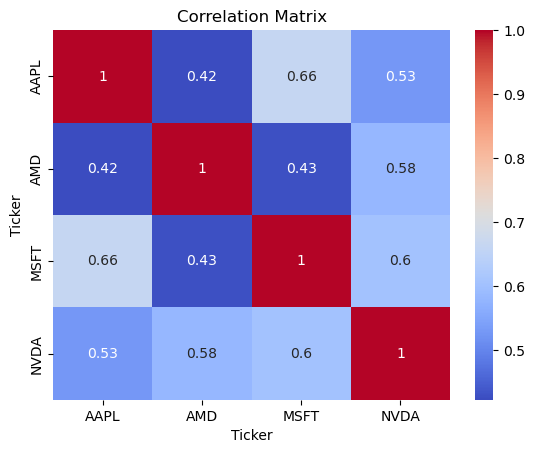

In [30]:
import seaborn as sns

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

One observation to be made is the fact that correlation between each stock ranges from 0.4 to 0.7, meaning they are positively correlated to one another. This is due to the fact that despite differing internal structure and business cycles, these stocks share a common exposure to market-wide factors, which drives their returns to move in a broadly similar way.

Note that it doesn't mean that there is an effect of causation between our studied stocks.

In [ ]:
def compute_stats(data):
    returns = data.pct_change().dropna() 
    returns = returns * 100
    stats = pd.DataFrame()
    stats["mean daily return"] = returns.mean()
    stats["yearly return"] = stats["mean daily return"] * TRADING_DAYS
    stats["yearly volatility"] = returns.std() *np.sqrt(TRADING_DAYS)
    return returns, stats

## Focused study and application: 2020 covid crisis

This part of the study will serve as means to exploit and expand tools built previously through a focused world wide crisis.

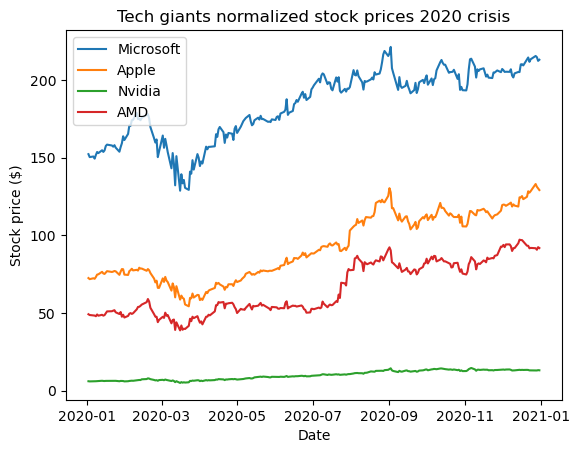

In [32]:
crisis = data.loc["2020-01-01":"2020-12-31"]

data_plot(crisis, tickers, label, "Tech giants normalized stock prices 2020 crisis", "Date", "Stock price ($)", "upper left")



In [33]:
returns_crisis , returns_stats_crisis = compute_stats(crisis)

returns_stats_crisis.head()


,mean daily return,yearly return,yearly volatility
Ticker,,,
AAPL,0.272751,68.733371,46.699328
AMD,0.320971,80.884795,60.855901
MSFT,0.171715,43.272077,43.939314
NVDA,0.376514,94.881466,57.912149


Surprisingly, despite lockdowns and the pandemic, performances of our study group were excellent in 2020. This shows that certain sectors can be impacted more than others in times of crisis. Yet the key study point is the correlation Matrix, which will give us insight as to how our study group acted one to another.

In [34]:
corr_matrix_crisis = returns_crisis.corr()
corr_matrix_crisis

Ticker,AAPL,AMD,MSFT,NVDA
Ticker,,,,
AAPL,1.000000,0.658647,0.839273,0.773978
AMD,0.658647,1.000000,0.683806,0.783485
MSFT,0.839273,0.683806,1.000000,0.842045
NVDA,0.773978,0.783485,0.842045,1.000000


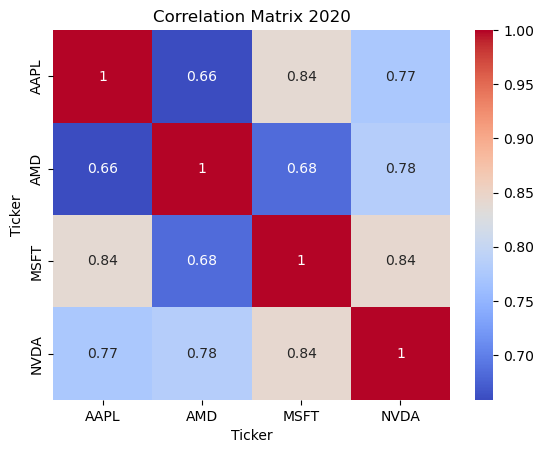

In [35]:
sns.heatmap(corr_matrix_crisis, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix 2020")
plt.show()

We can firstly see that our tech giants are heavily correlated one to another, as a matter of fact, the lowest correlation factor in 2020 equates to the highest factor on the 10 year study. This shows that during market stress, correlation between actors of an industry increases, their behavior tends to follow the same framework. This reduces portfolio diversification exactly when you need it the most.

In [36]:

returns_stats_crisis.head()

,mean daily return,yearly return,yearly volatility
Ticker,,,
AAPL,0.272751,68.733371,46.699328
AMD,0.320971,80.884795,60.855901
MSFT,0.171715,43.272077,43.939314
NVDA,0.376514,94.881466,57.912149


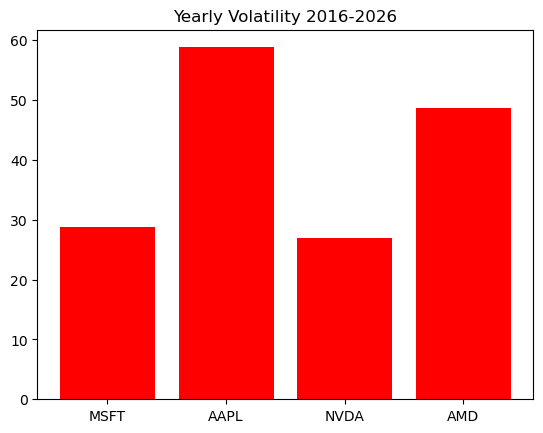

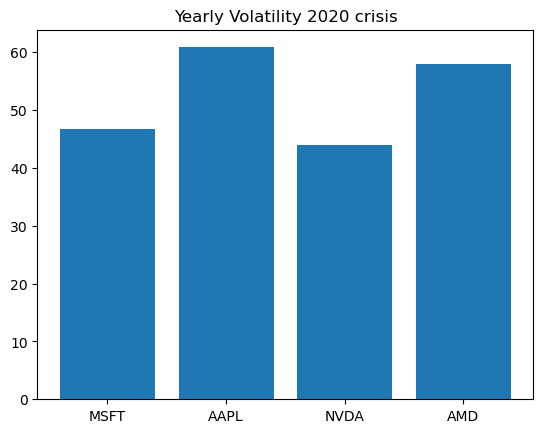

In [38]:
plt.bar(tickers,returns_stats["Yearly Volatility"], color="r")

plt.title("Yearly Volatility 2016-2026")
plt.show();

plt.bar(tickers,returns_stats_crisis["yearly volatility"])
plt.title("Yearly Volatility 2020 crisis")
plt.show();

On average, volatility was greater during the 2020 crisis, mainly due to market uncertainty and instability. It is valuable to retain the fact that over a longer study period, volatility is smoothed. However we can still state that under market tension, volatility and risk increases for the portfolio owner.

# Conclusion

This project aimed to explore the fundamental characteristics of financial assets through the analysis of major technology stocks, focusing on returns, volatility, and correlations.

The results highlight clear differences in performance and risk profiles across assets. In particular, Nvidia stands out with significantly higher returns, but this performance is accompanied by substantially higher volatility, illustrating the classic risk-return tradeoff. In contrast, companies such as Microsoft and Apple exhibit more moderate returns with lower levels of risk.

The correlation analysis reveals strong positive relationships between the selected stocks, reflecting their exposure to the same sector. This limits the effectiveness of diversification within a technology-only portfolio. Moreover, the analysis of crisis periods shows that correlations tend to increase during market stress, reducing diversification benefits precisely when they are most needed. These periods are also characterized by sharp increases in volatility, emphasizing the dynamic nature of financial risk.

Overall, this study demonstrates that relying solely on technology stocks does not provide sufficient diversification. A well-balanced portfolio requires exposure to multiple sectors and asset classes. More broadly, the results reinforce a key principle of finance: higher expected returns are typically associated with higher levels of risk.

This project provides a foundation for further analysis, particularly in portfolio construction and optimization, where these concepts can be applied to build more efficient investment strategies.